Cell 1 — Install Kaggle and required libraries

In [1]:
# Install Kaggle API and the libraries needed for the CNN prototype.
# TensorFlow builds the CNN, while NumPy, Pandas and Matplotlib handle the data.

!pip -q install kaggle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

Cell 2 — Upload Kaggle API key

In [2]:
# Upload your Kaggle API key so Colab can access the dataset.
# The key is copied to the required Kaggle folder for authentication.

from google.colab import files

uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API key is ready.")

Saving archive.zip to archive.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key is ready.


Cell 3 — Download MNIST from Kaggle

In [3]:
# Download the MNIST CSV dataset from Kaggle into the Colab environment.
# The downloaded ZIP file will be extracted into the /content/mnist_data folder.

!mkdir -p /content/mnist_data

!kaggle datasets download -d oddrationale/mnist-in-csv \
    -p /content/mnist_data

!unzip -o /content/mnist_data/mnist-in-csv.zip \
    -d /content/mnist_data

print("MNIST dataset downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
100% 15.2M/15.2M [00:00<00:00, 103MB/s] 

Archive:  /content/mnist_data/mnist-in-csv.zip
  inflating: /content/mnist_data/mnist_test.csv  
  inflating: /content/mnist_data/mnist_train.csv  
MNIST dataset downloaded successfully.


Cell 4 — Check the files

In [4]:
# Display the downloaded files so we can confirm that the dataset is available.
# This helps us identify the correct CSV filenames before loading the data.

!find /content/mnist_data -maxdepth 2 -type f

/content/mnist_data/mnist_train.csv
/content/mnist_data/mnist_test.csv
/content/mnist_data/mnist-in-csv.zip


Cell 5 — Read the CSV files

In [5]:
# Read the training and testing CSV files into Pandas DataFrames.
# Each row contains one handwritten digit and its 784 pixel values.

train_df = pd.read_csv("/content/mnist_data/mnist_train.csv")
test_df = pd.read_csv("/content/mnist_data/mnist_test.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

display(train_df.head())

Training data shape: (60000, 785)
Testing data shape: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Cell 6 — Separate images and labels

In [6]:
# Separate the label column from the 784 pixel columns.
# The labels are the correct answers, while the pixels are the CNN input.

label_column = "label"

X = train_df.drop(columns=[label_column]).values
y = train_df[label_column].values

X_test_external = test_df.drop(columns=[label_column]).values
y_test_external = test_df[label_column].values

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (60000, 784)
Labels: (60000,)


Cell 7 — Check the labels

In [7]:
# Display the unique digit classes present in the training and test data.
# This confirms that the model will learn ten classes from 0 to 9.

print("Training labels:", np.unique(y))
print("Testing labels:", np.unique(y_test_external))
print("Number of classes:", len(np.unique(y)))

Training labels: [0 1 2 3 4 5 6 7 8 9]
Testing labels: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


Cell 8 — Display a sample digit

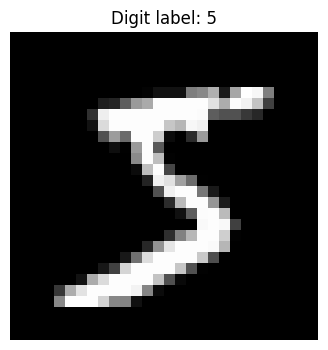

In [8]:
# Reshape the first 784 pixels into a 28x28 image and display the digit.
# This shows how numerical pixel values represent a handwritten digit.

plt.figure(figsize=(4, 4))
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"Digit label: {y[0]}")
plt.axis("off")
plt.show()

Cell 9 — Display multiple digits

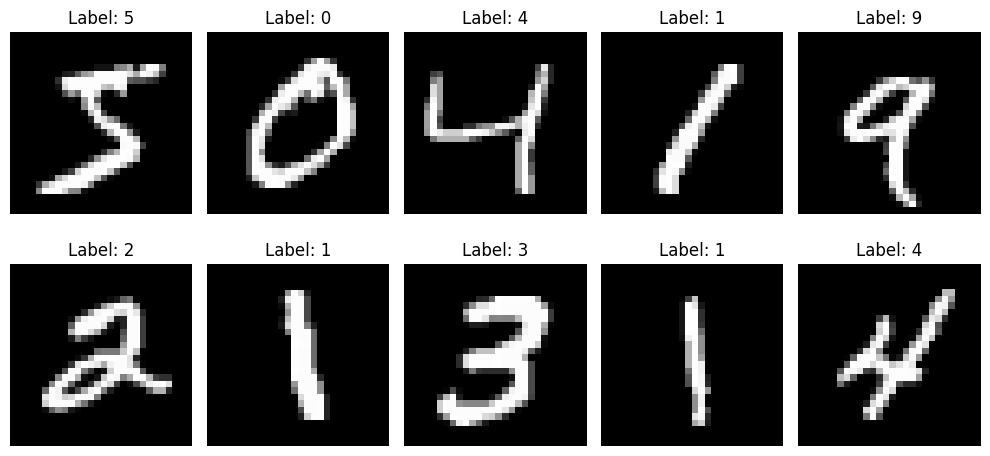

In [9]:
# Display several handwritten digits from the dataset for visual understanding.
# Each image is reconstructed from its 784 numerical pixel values.

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Cell 10 — Normalize pixel values

In [10]:
# Convert pixel values from 0-255 into the range 0-1 for easier CNN training.
# Floating-point conversion ensures the division produces decimal values.

X = X.astype("float32") / 255.0
X_test_external = X_test_external.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Cell 11 — Reshape images for CNN

In [11]:
# Reshape flat 784-pixel vectors into 28x28 images with one grayscale channel.
# CNN expects image data in the format: samples, height, width, channels.

X = X.reshape(-1, 28, 28, 1)
X_test_external = X_test_external.reshape(-1, 28, 28, 1)

print("CNN training input shape:", X.shape)
print("CNN test input shape:", X_test_external.shape)

CNN training input shape: (60000, 28, 28, 1)
CNN test input shape: (10000, 28, 28, 1)


Cell 12 — Split training and validation data

In [12]:
# Split the training images into training and validation sets.
# Validation data checks how well the CNN performs on images it did not train on.

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 48000
Validation samples: 12000


Cell 13 — Create the CNN model

In [13]:
# Build a CNN with two convolution layers, two pooling layers and a dense layer.
# The final softmax layer produces probabilities for the ten digit classes.

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Cell 14 — Compile the model

In [14]:
# Configure the optimizer, loss function and accuracy metric for training.
# Adam updates weights, sparse categorical crossentropy measures classification error.

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


Cell 15 — Train the model

In [15]:
# Train the CNN using the training images and labels.
# Validation data measures accuracy and loss after each training epoch.

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.9165 - loss: 0.2733 - val_accuracy: 0.9749 - val_loss: 0.0827
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9770 - loss: 0.0767 - val_accuracy: 0.9847 - val_loss: 0.0515
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 81ms/step - accuracy: 0.9844 - loss: 0.0523 - val_accuracy: 0.9872 - val_loss: 0.0428
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.9870 - loss: 0.0430 - val_accuracy: 0.9868 - val_loss: 0.0441
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.9891 - loss: 0.0349 - val_accuracy: 0.9883 - val_loss: 0.0406
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.9903 - loss: 0.0304 - val_accuracy: 0.9894 - val_loss: 0.0385
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.9918 - loss: 0.0245 - val_accuracy: 0.9878 - val_loss: 0.0427
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.9931 - loss: 0.0215 - 

Cell 16 — Plot training accuracy and validation accuracy

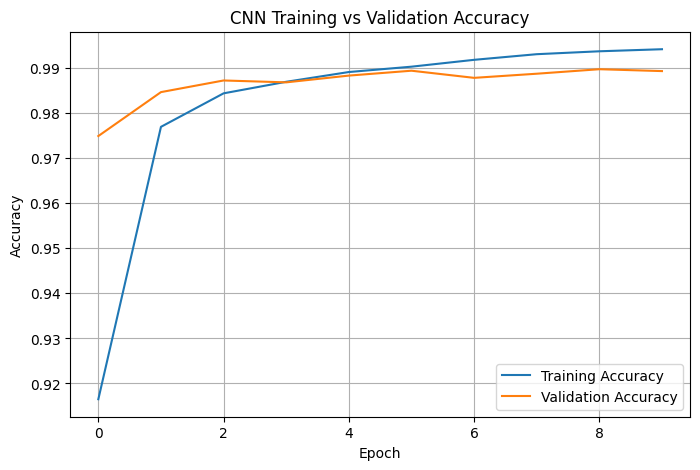

In [16]:
# Plot the training and validation accuracy to see how the CNN learns.
# These curves help identify improvement or possible overfitting during training.

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Cell 17 — Plot training and validation loss

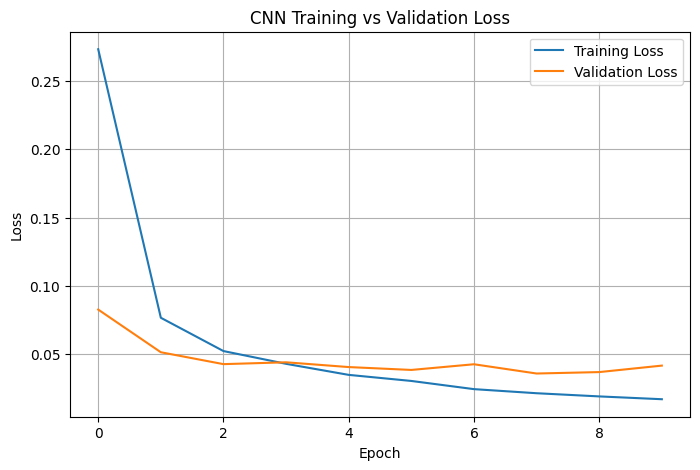

In [17]:
# Plot the training and validation loss to observe the model's classification error.
# Lower loss generally indicates that the model is learning better predictions.

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Cell 18 — Evaluate on validation data

In [18]:
# Evaluate the trained CNN on the validation images that were not used for training.
# The output gives the loss and accuracy on unseen validation samples.

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=1
)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_accuracy)
print("Validation accuracy percentage:", val_accuracy * 100)

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9893 - loss: 0.0417
Validation loss: 0.04167982563376427
Validation accuracy: 0.9893333315849304
Validation accuracy percentage: 98.93333315849304


Cell 19 — Evaluate on the Kaggle test dataset

In [19]:
# Evaluate the CNN on the separate Kaggle test dataset with known labels.
# This provides an additional accuracy measurement on 10,000 test images.

test_loss, test_accuracy = model.evaluate(
    X_test_external,
    y_test_external,
    verbose=1
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test accuracy percentage:", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9892 - loss: 0.0315
Test loss: 0.031488943845033646
Test accuracy: 0.9891999959945679
Test accuracy percentage: 98.91999959945679


Cell 20 — Predict one digit

In [20]:
# Select one test image and ask the trained CNN to predict its digit.
# The model returns ten probabilities, and argmax chooses the highest probability.

sample_index = 0

sample_image = X_test_external[sample_index:sample_index + 1]

prediction_probabilities = model.predict(sample_image)

predicted_digit = np.argmax(prediction_probabilities[0])

actual_digit = y_test_external[sample_index]

print("Predicted digit:", predicted_digit)
print("Actual digit:", actual_digit)
print("Prediction confidence:", prediction_probabilities[0][predicted_digit])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted digit: 7
Actual digit: 7
Prediction confidence: 0.99999857


Cell 21 — Display the predicted digit

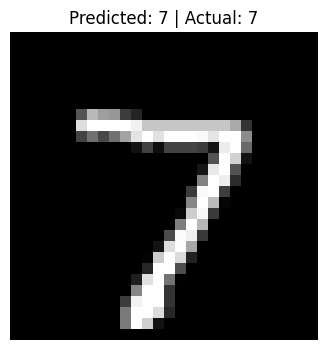

In [21]:
# Display the image together with the CNN's predicted and actual digit labels.
# This helps visually verify whether the model recognized the handwritten number.

plt.figure(figsize=(4, 4))

plt.imshow(
    sample_image[0].reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_digit} | Actual: {actual_digit}"
)

plt.axis("off")
plt.show()

Cell 22 — Predict multiple digits

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


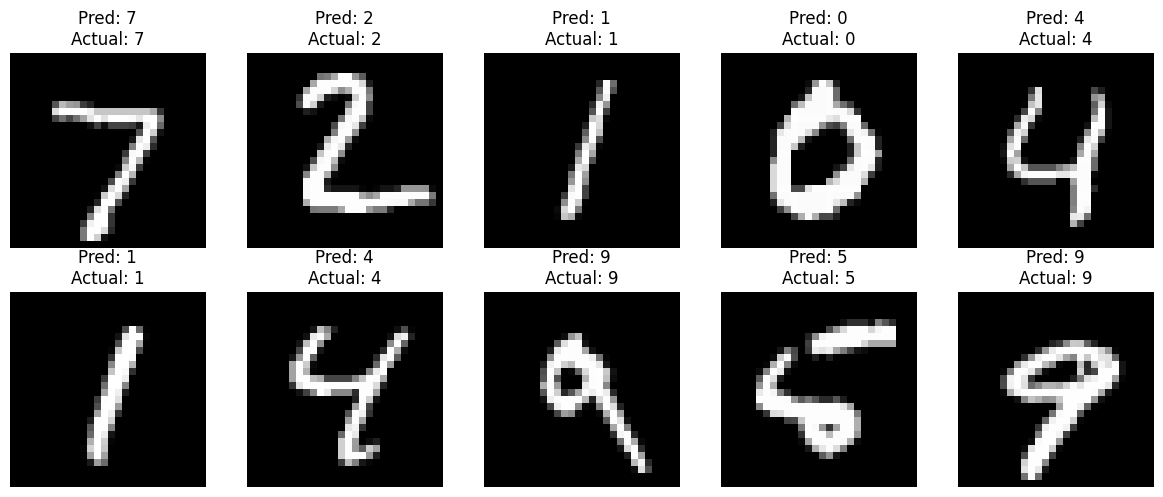

In [22]:
# Predict the first 10 test images and display their predicted digit classes.
# This demonstrates that the trained CNN can classify several images at once.

sample_images = X_test_external[:10]
sample_labels = y_test_external[:10]

probabilities = model.predict(sample_images)
predicted_digits = np.argmax(probabilities, axis=1)

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predicted_digits[i]}\nActual: {sample_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Cell 23 — Generate predictions for the validation set

In [23]:
# Generate predictions for every image in the validation dataset.
# The predicted class is the digit with the highest output probability.

val_probabilities = model.predict(X_val)
val_predictions = np.argmax(val_probabilities, axis=1)

print("Number of validation predictions:", len(val_predictions))

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Number of validation predictions: 12000


Cell 24 — Plot confusion matrix

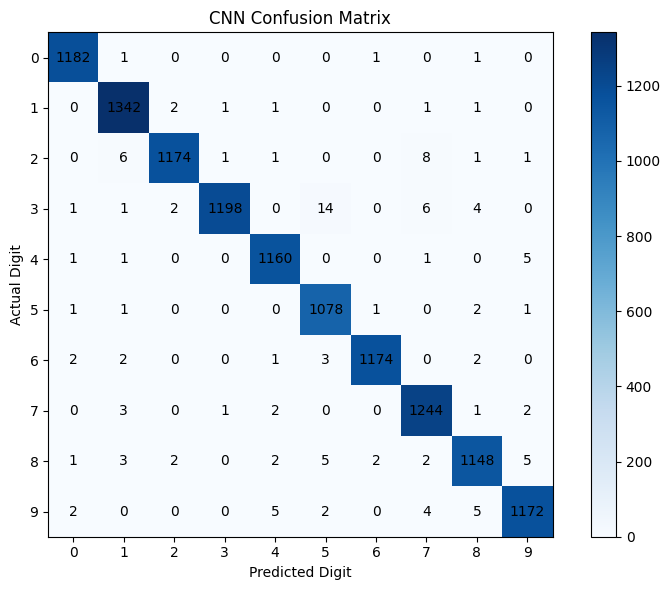

In [24]:
# Create a confusion matrix showing actual digits against predicted digits.
# Diagonal values represent correct predictions, while off-diagonal values are errors.

cm = confusion_matrix(y_val, val_predictions)

plt.figure(figsize=(8, 6))

plt.imshow(cm, cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

Cell 25 — Classification report

In [25]:
# Generate precision, recall and F1-score for each digit class.
# This provides detailed performance information beyond overall accuracy.

print(
    classification_report(
        y_val,
        val_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9933    0.9975    0.9954      1185
           1     0.9868    0.9955    0.9911      1348
           2     0.9949    0.9849    0.9899      1192
           3     0.9975    0.9772    0.9872      1226
           4     0.9898    0.9932    0.9915      1168
           5     0.9782    0.9945    0.9863      1084
           6     0.9966    0.9916    0.9941      1184
           7     0.9826    0.9928    0.9877      1253
           8     0.9854    0.9812    0.9833      1170
           9     0.9882    0.9849    0.9865      1190

    accuracy                         0.9893     12000
   macro avg     0.9893    0.9893    0.9893     12000
weighted avg     0.9894    0.9893    0.9893     12000



Cell 26 — Save the model

In [26]:
# Save the complete trained CNN so it can be reused without retraining.
# The saved file contains the model architecture, weights and training configuration.

model.save("/content/mnist_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


Cell 27 — Load the saved model

In [27]:
# Load the previously saved CNN model from the Colab file system.
# This allows us to make predictions using the saved model.

loaded_model = tf.keras.models.load_model(
    "/content/mnist_cnn_model.keras"
)

print("Saved CNN model loaded successfully.")

Saved CNN model loaded successfully.


Cell 28 — Test the loaded model

In [28]:
# Use the loaded model to predict one test image and verify that it works.
# The predicted class is obtained from the highest softmax probability.

loaded_probabilities = loaded_model.predict(
    X_test_external[:1]
)

loaded_prediction = np.argmax(loaded_probabilities[0])

print("Prediction from loaded model:", loaded_prediction)
print("Actual digit:", y_test_external[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction from loaded model: 7
Actual digit: 7


Cell 29 — Upload a digit image

In [29]:
# Upload a handwritten digit image from your computer for prediction.
# The uploaded image will be converted into the 28x28 grayscale format expected by the CNN.

from google.colab import files
from PIL import Image, ImageOps

uploaded_image = files.upload()

image_filename = list(uploaded_image.keys())[0]

print("Uploaded image:", image_filename)

Saving Screenshot 2026-09-16 004941.png to Screenshot 2026-09-16 004941.png
Uploaded image: Screenshot 2026-09-16 004941.png


Cell 30 — Preprocess the uploaded image

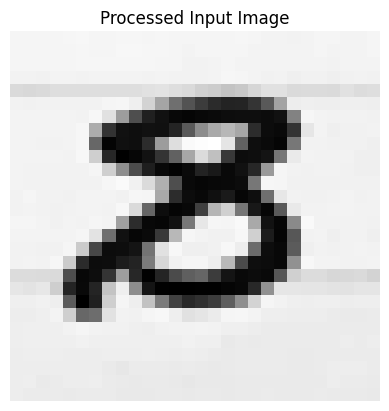

In [30]:
# Convert the uploaded image to grayscale and resize it to 28x28 pixels.
# Normalize the pixel values and add batch and channel dimensions for the CNN.

img = Image.open(image_filename).convert("L")
img = img.resize((28, 28))

img_array = np.array(img).astype("float32") / 255.0

img_array = img_array.reshape(1, 28, 28, 1)

plt.imshow(img_array[0].reshape(28, 28), cmap="gray")
plt.title("Processed Input Image")
plt.axis("off")
plt.show()

Cell 31 — Predict your own digit

In [31]:
# Use the trained CNN to predict the handwritten digit from the uploaded image.
# The class with the highest probability is displayed as the final prediction.

custom_probabilities = loaded_model.predict(img_array)

custom_prediction = np.argmax(custom_probabilities[0])

print("Predicted handwritten digit:", custom_prediction)
print(
    "Confidence:",
    custom_probabilities[0][custom_prediction]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted handwritten digit: 3
Confidence: 0.93222696
